# Computational Intelligence Project: Island Genetic Algorithm

This notebook demonstrates the incremental implementation of an advanced Genetic Algorithm (GA) to solve a variation of the Vehicle Routing Problem (VRP) with non-linear costs. 

## The Problem
We need to collect gold from $N$ cities and return it to a base (0). 
**Cost Function**: $c(d, w) = d + (\alpha \cdot d \cdot w)^\beta$

Where $\beta$ can be high (e.g., 5.0), making heavy loads extremely expensive over distance.

In [1]:
import logging
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict

# Import from our unified codebase
from problem import Problem
from src.solver import GA_Solver
from src.utils import calculate_metrics

logging.basicConfig(level=logging.INFO, format='%(message)s')

## 1. Problem Definition
We use the shared `Problem` class to generate the graph and calculate costs.

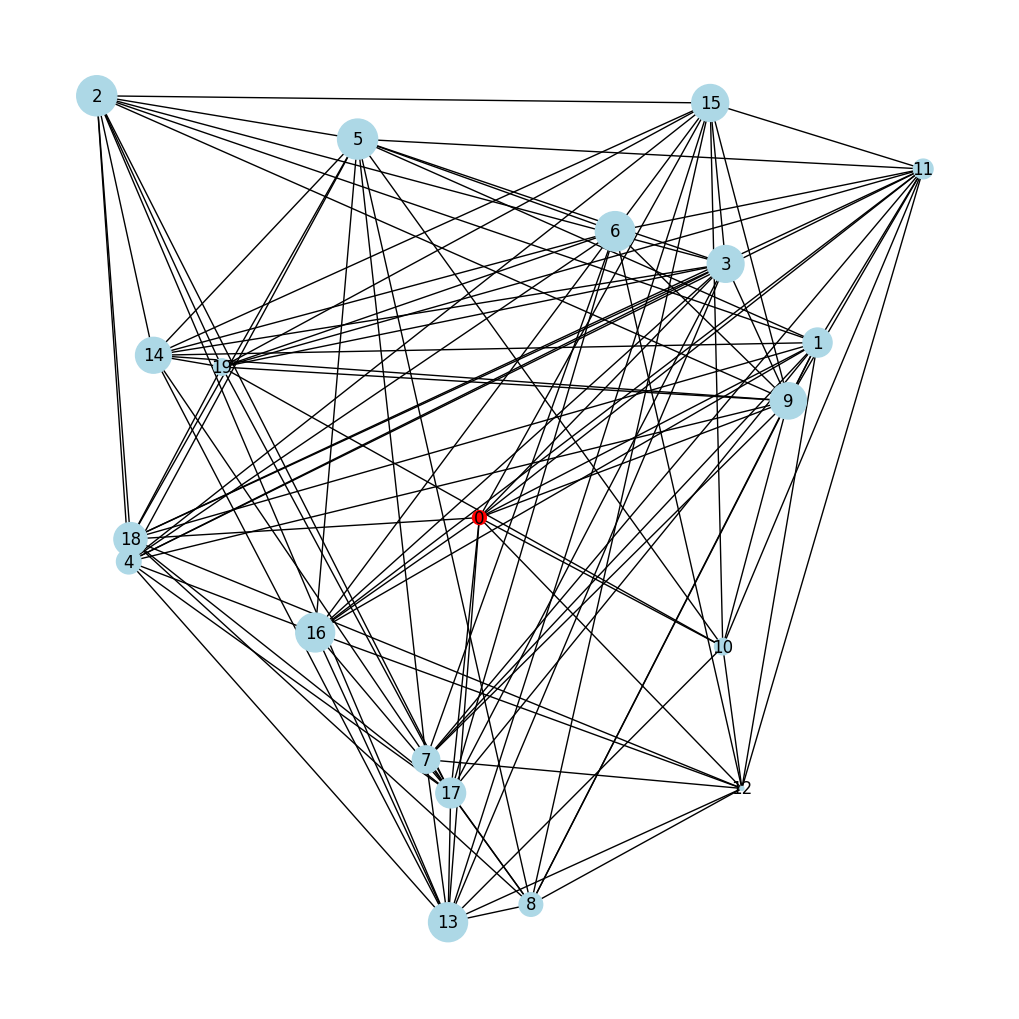

In [2]:
# Initialize Problem
problem = Problem(num_cities=20, alpha=0.3,beta=0.2,density=0.5, seed=42)
problem.plot()
plt.show()

### 1.1 Problem Baseline

In [3]:
baseline_cost = problem.baseline()
print(f"Baseline Cost: {baseline_cost:.2e}")

Baseline Cost: 7.78e+01


## 2. Solution Strategy: Island GA + Virtual Nodes
We use the `GA_Solver` class which encapsulates:
1.  **Virtual Nodes**: Splitting heavy cities.
2.  **Island Model**: 4 distinct populations (Exploit, Balanced, Explore, Chaos).
3.  **Adaptive Parameters**: Evolving mutation rates and window sizes.

We will run the solver step-by-step.

In [4]:
# Initialize Solver
solver = GA_Solver(problem, pop_size_per_island=80)

print(f"Initial Best Cost: {solver.global_best.cost:.2e}")

Initial Best Cost: 5.23e+01


## 3. Running the Evolution
We can step through generations and observe the convergence.

In [5]:
generations = 100
history = {'gen': [], 'best_cost': []}

for g in range(generations):
    stats = solver.step_generation()
    
    history['gen'].append(stats['gen'])
    history['best_cost'].append(stats['best_cost'])
    
    if g % 10 == 0:
        print(f"Gen {g}: Best Cost {stats['best_cost']:.4e}")

Gen 0: Best Cost 5.1647e+01
Gen 10: Best Cost 4.9824e+01
Gen 20: Best Cost 4.9686e+01
Gen 30: Best Cost 4.9686e+01
Gen 40: Best Cost 4.9577e+01
Gen 50: Best Cost 4.9577e+01
Gen 60: Best Cost 4.9577e+01
Gen 70: Best Cost 4.9577e+01
Gen 80: Best Cost 4.9577e+01
Gen 90: Best Cost 4.9577e+01


In [7]:
best_ind = solver.global_best
formatted_solution = []
        
# best_ind.trips is a list of lists, e.g., [[v1, v2], [v3, v4]]
for trip in best_ind.trips:
    for v_node in trip:
            # Map virtual node ID back to real city ID
        real_node = solver.virtual_map[v_node]
            # distinct gold amount for this specific virtual chunk
        gold_amount = solver.node_golds[v_node]
                
        formatted_solution.append((real_node, gold_amount))
            
    # Append "Return to Base" (City 0, 0 Gold) after every trip
    formatted_solution.append((0, 0))

In [8]:
formatted_solution

[(10, 140.6127311257005),
 (1, 437.7147669534584),
 (9, 682.8130084710006),
 (0, 0),
 (12, 8.354907481254507),
 (7, 388.0909006511443),
 (8, 289.03977582631387),
 (13, 787.1374531246363),
 (17, 459.4568597628016),
 (0, 0),
 (4, 313.054274740659),
 (16, 780.9483019909459),
 (0, 0),
 (18, 569.1724547569409),
 (0, 0),
 (19, 140.6572011295298),
 (14, 665.1860057354401),
 (2, 832.8455178617796),
 (5, 832.4275415938058),
 (6, 804.9595931393051),
 (0, 0),
 (11, 200.70829427263322),
 (15, 705.4602132477088),
 (3, 700.5648369002469),
 (0, 0)]

In [9]:
print(f"\nFinal Solution Cost: {solver.global_best.cost:.4e}")

print(f"Returned base {formatted_solution.count((0, 0))-1} times")


Final Solution Cost: 4.9577e+01
Returned base 5 times


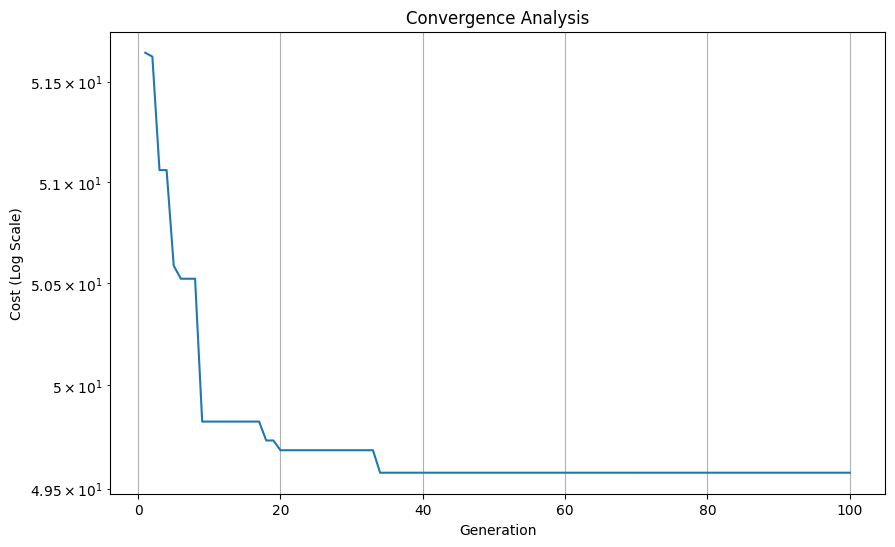

In [10]:
# Plot Convergence
plt.figure(figsize=(10, 6))
plt.plot(history['gen'], history['best_cost'])
plt.yscale('log')
plt.title('Convergence Analysis')
plt.xlabel('Generation')
plt.ylabel('Cost (Log Scale)')
plt.grid(True)
plt.show()

## 4. Comparison with Baseline
We compare our result against the simple Dijkstra baseline.

In [11]:
baseline_cost = problem.baseline()
print(f"Baseline Cost: {baseline_cost:.2e}")
print(f"My Solution Cost: {solver.global_best.cost:.2e}")

if solver.global_best.cost < baseline_cost:
    factor = baseline_cost / solver.global_best.cost
    print(f"Improvement Factor: {factor:.5f}x better")
else:
    print("No improvement.")

Baseline Cost: 7.78e+01
My Solution Cost: 4.96e+01
Improvement Factor: 1.56932x better


# 5. Full Experimentation

I'm definitely way stronger than baseline when Beta is high but the same solution seems to be stuck in local optima when Beta = 1. We have to make our split count (how much we return to base), our tour mechanics (are we starting from the furher cities, or the nearest cities), and our chunking (are we splitting the tour into chunks, or are we just doing one big tour) more adaptive to the problem.

To do this, I need to first analyze the statistics of my solution with an experimentation grid.

In [12]:
import sys
import os
import csv

from problem import Problem
from s347896 import solution

In [13]:
# EXTREME EXPERIMENT
DENSITIES = [0.05,0.95]
BETAS = [
    0.0001,
    0.001,
    0.01,
    0.3,
    1.0]
NUM_CITIES_LIST = [15]
ALPHAS = [
    0.00000001,
    0.000001,
    0.0001,
    1,
    10000,
    1000000,
    10000000.0]

# Prepare CSV file
csv_columns = ["graph_density","alpha", "beta", "num_cities", "split_count", "improvement_factor", "tour_sequence", "distances_between_cities", "gold_carried_at_each_step", "status", "error"]
csv_file = "mechanics_analysis_extreme.csv"

# Collect plot data as we go
plot_data = {} 

In [16]:
# DOCILE EXPERIMENT
DENSITIES = [0.40,0.60]
BETAS = [
    0.1,
    0.6,
    1.0,
    1.2,
    1.45
    ]
NUM_CITIES_LIST = [15]
ALPHAS = [0.25,1,15]

# Prepare CSV file
csv_columns = ["graph_density","alpha", "beta", "num_cities", "split_count", "improvement_factor", "tour_sequence", "distances_between_cities", "gold_carried_at_each_step", "status", "error"]
csv_file = "mechanics_analysis_docile.csv"

# Collect plot data as we go
plot_data = {} 

In [18]:
# LARGE EXPERIMENT
DENSITIES = [0.5]
BETAS = [
    0.0000000001,
    0.00001,
    0.001,
    0.1,
    0.5,
    0.9,
    1.0,
    1.1,
    1.2,
    1.3,
    ]
NUM_CITIES_LIST = [15]
ALPHAS = [0.0000000001,0.00001,0.001,0.1,0.25,1,5,10,100,1000,10000,1000000000]

# Prepare CSV file
csv_columns = ["graph_density","alpha", "beta", "num_cities", "split_count", "improvement_factor", "tour_sequence", "distances_between_cities", "gold_carried_at_each_step", "status", "error"]
csv_file = "mechanics_analysis_large.csv"

# Collect plot data as we go
plot_data = {} 

In [17]:
with open(csv_file, 'w', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=csv_columns)
    writer.writeheader()

    for num_cities in NUM_CITIES_LIST:
        for density in DENSITIES:
            for alpha in ALPHAS:
                for beta in BETAS:
                    # Basic row info
                    row = {
                        "graph_density": density,
                        "alpha": alpha,
                        "beta": beta,
                        "num_cities": num_cities,
                        "split_count": 0,
                        "improvement_factor": 0.0,
                        "tour_sequence": "",
                        "distances_between_cities": "",
                        "gold_carried_at_each_step": "",
                        "status": "pending",
                        "error": ""
                    }
                    try:
                        p = Problem(num_cities, alpha=alpha, beta=beta, density=density, seed=42)
                        baseline_c = p.baseline()
                        
                        # Run GA Solution
                        sol_seq = solution(p)
                        
                        # Metrics
                        splits, dists, golds, imp = calculate_metrics(p, sol_seq, baseline_c)
                        
                        row.update({
                            "split_count": splits,
                            "improvement_factor": round(imp, 4),
                            # Store complex lists as JSON-like strings
                            "tour_sequence": str([int(x[0]) for x in sol_seq]),
                            "distances_between_cities": str([round(x, 4) for x in dists]),
                            "gold_carried_at_each_step": str([round(x, 4) for x in golds]),
                            "status": "success",
                            "error": ""
                        })
                        
                        # Store for plotting
                        group_key = (density, num_cities)
                        if group_key not in plot_data:
                            plot_data[group_key] = {'x': [], 'y': []}
                        plot_data[group_key]['x'].append(beta)
                        plot_data[group_key]['y'].append(imp)
                        
                        # Print small progress indicator
                        print(f"Completed N={num_cities}, D={density}, A={alpha}, B={beta} -> Imp={round(imp, 4)}x \n\n", flush=True)

                    except Exception as ex:
                        row.update({
                            "status": "failure",
                            "error": str(ex)
                        })
                        print(f"Failed N={num_cities}, D={density},A={alpha}, B={beta}: {ex}", flush=True)
                    
                    writer.writerow(row)


============================== SOLVER CONFIGURATION ==============================
[Instance]  N=15   | Alpha=0.2  | Beta=0.1  | Density=0.47
[Stats]     Avg Dist=0.417 | Avg Gold=490.0
[Estimate]  Complexity Factor: 1.84
[Planning]  Est. Virtual Nodes: ~15 (Split Factor: 1.00x)
[Budget]    Total Evals: 3427 | Pop: 150 (50/isl) | Gens: 30

Completed N=15, D=0.4, A=0.25, B=0.1 -> Imp=1.7754x 



============================== SOLVER CONFIGURATION ==============================
[Instance]  N=15   | Alpha=0.2  | Beta=0.6  | Density=0.47
[Stats]     Avg Dist=0.417 | Avg Gold=490.0
[Estimate]  Complexity Factor: 2.02
[Planning]  Est. Virtual Nodes: ~15 (Split Factor: 1.00x)
[Budget]    Total Evals: 3763 | Pop: 72 (24/isl) | Gens: 52

Completed N=15, D=0.4, A=0.25, B=0.6 -> Imp=1.2988x 



============================== SOLVER CONFIGURATION ==============================
[Instance]  N=15   | Alpha=0.2  | Beta=1.0  | Density=0.47
[Stats]     Avg Dist=0.417 | Avg Gold=490.0
[Estimate]  Comple

CHUNKING FINALIZED: 200 virtual nodes created (Expansion: 14.29x). Beta=1.2



============================== SOLVER CONFIGURATION ==============================
[Instance]  N=15   | Alpha=0.2  | Beta=1.2  | Density=0.47
[Stats]     Avg Dist=0.417 | Avg Gold=490.0
[Estimate]  Complexity Factor: 4.31
[Planning]  Est. Virtual Nodes: ~207 (Split Factor: 13.85x)
[Budget]    Total Evals: 4232 | Pop: 54 (18/isl) | Gens: 78

Completed N=15, D=0.4, A=0.25, B=1.2 -> Imp=1.5118x 




CHUNKING FINALIZED: 366 virtual nodes created (Expansion: 26.14x). Beta=1.45



============================== SOLVER CONFIGURATION ==============================
[Instance]  N=15   | Alpha=0.2  | Beta=1.4  | Density=0.47
[Stats]     Avg Dist=0.417 | Avg Gold=490.0
[Estimate]  Complexity Factor: 5.04
[Planning]  Est. Virtual Nodes: ~403 (Split Factor: 26.92x)
[Budget]    Total Evals: 3342 | Pop: 43 (14/isl) | Gens: 77

Completed N=15, D=0.4, A=0.25, B=1.45 -> Imp=3.6287x 



============================== SOLVER CONFIGURATION ==============================
[Instance]  N=15   | Alpha=1.0  | Beta=0.1  | Density=0.47
[Stats]     Avg Dist=0.417 | Avg Gold=490.0
[Estimate]  Complexity Factor: 1.84
[Planning]  Est. Virtual Nodes: ~15 (Split Factor: 1.00x)
[Budget]    Total Evals: 3427 | Pop: 150 (50/isl) | Gens: 30

Completed N=15, D=0.4, A=1, B=0.1 -> Imp=1.7574x 



============================== SOLVER CONFIGURATION ==============================
[Instance]  N=15   | Alpha=1.0  | Beta=0.6  | Density=0.47
[Stats]     Avg Dist=0.417 | Avg Gold=490.0
[Estimate]  Comple

...


============================== SOLVER CONFIGURATION ==============================
[Instance]  N=15   | Alpha=1.0  | Beta=1.4  | Density=0.70
[Stats]     Avg Dist=0.417 | Avg Gold=490.0
[Estimate]  Complexity Factor: 5.38
[Planning]  Est. Virtual Nodes: ~600 (Split Factor: 40.00x)
[Budget]    Total Evals: 3000 | Pop: 35 (11/isl) | Gens: 85

Completed N=15, D=0.6, A=1, B=1.45 -> Imp=4.7644x 



============================== SOLVER CONFIGURATION ==============================
[Instance]  N=15   | Alpha=15.0 | Beta=0.1  | Density=0.70
[Stats]     Avg Dist=0.417 | Avg Gold=490.0
[Estimate]  Complexity Factor: 1.84
[Planning]  Est. Virtual Nodes: ~15 (Split Factor: 1.00x)
[Budget]    Total Evals: 3427 | Pop: 142 (47/isl) | Gens: 30

Completed N=15, D=0.6, A=15, B=0.1 -> Imp=1.5475x 



============================== SOLVER CONFIGURATION ==============================
[Instance]  N=15   | Alpha=15.0 | Beta=0.6  | Density=0.70
[Stats]     Avg Dist=0.417 | Avg Gold=490.0
[Estimate]  Complexi

CHUNKING FINALIZED: 490 virtual nodes created (Expansion: 35.00x). Beta=1.2



============================== SOLVER CONFIGURATION ==============================
[Instance]  N=15   | Alpha=15.0 | Beta=1.2  | Density=0.70
[Stats]     Avg Dist=0.417 | Avg Gold=490.0
[Estimate]  Complexity Factor: 5.17
[Planning]  Est. Virtual Nodes: ~600 (Split Factor: 40.00x)
[Budget]    Total Evals: 3000 | Pop: 38 (12/isl) | Gens: 78

Completed N=15, D=0.6, A=15, B=1.2 -> Imp=2.0285x 




CHUNKING FINALIZED: 490 virtual nodes created (Expansion: 35.00x). Beta=1.45



============================== SOLVER CONFIGURATION ==============================
[Instance]  N=15   | Alpha=15.0 | Beta=1.4  | Density=0.70
[Stats]     Avg Dist=0.417 | Avg Gold=490.0
[Estimate]  Complexity Factor: 5.38
[Planning]  Est. Virtual Nodes: ~600 (Split Factor: 40.00x)
[Budget]    Total Evals: 3000 | Pop: 35 (11/isl) | Gens: 85

Completed N=15, D=0.6, A=15, B=1.45 -> Imp=4.9641x 




In [15]:
import matplotlib.pyplot as plt
import csv
import glob
import os
import math

# Define the configurations (Input CSV -> Output Folder)
CONFIGS = [
    {
        'input_pattern': 'mechanics_analysis_extreme*.csv', 
        'folder': 'extreme_parameters',
        'title_suffix': '(Extreme)'
    },
    {
        'input_pattern': 'mechanics_analysis_docile*.csv', 
        'folder': 'docile_parameters',
        'title_suffix': '(Docile)'
    },
    {
        'input_pattern': 'mechanics_analysis_large*.csv', 
        'folder': 'full_parameters',
        'title_suffix': '(Full)'
    }
]

def load_data_from_csv(pattern):
    # Find latest file matching pattern
    files = glob.glob(pattern) + glob.glob(f'src/{pattern}')
    if not files:
        return None
    
    files.sort(key=os.path.getmtime, reverse=True)
    target_csv = files[0]
    print(f"[{pattern}] Loading from {target_csv}...")
    
    data = []
    try:
        with open(target_csv, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                try:
                    res = {
                        'alpha': float(row.get('alpha', 0)),
                        'beta': float(row.get('beta', 0)),
                        'density': float(row.get('graph_density', 0)),
                        'imp': float(row.get('improvement_factor') or row.get('imp', 0)),
                        'num_cities': int(row.get('num_cities', 0))
                    }
                    data.append(res)
                except ValueError: continue
    except Exception as e:
        print(f"Error reading {target_csv}: {e}")
        return None
        
    return data

def generate_plots(results, folder, title_suffix):
    # Create directory
    os.makedirs(folder, exist_ok=True)
    print(f"Generating plots in '{folder}/'...")

    # 1. Beta vs Improvement Factor (grouped by Alpha)
    data_by_alpha = {}
    for r in results:
        a = r['alpha']
        if a not in data_by_alpha: data_by_alpha[a] = {'x': [], 'y': []}
        data_by_alpha[a]['x'].append(r['beta'])
        data_by_alpha[a]['y'].append(r['imp'])

    plt.figure(figsize=(10, 6))
    for alpha, data in sorted(data_by_alpha.items()):
        sorted_pairs = sorted(zip(data['x'], data['y']))
        xs = [val[0] for val in sorted_pairs]
        ys = [val[1] for val in sorted_pairs]
        plt.plot(xs, ys, marker='o', label=f'Alpha={alpha}')

    plt.xlabel('Beta')
    plt.ylabel('Improvement Factor')
    plt.title(f'Beta vs. Improvement {title_suffix}')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'{folder}/beta_vs_improvement_by_alpha.png')
    plt.close()

    # 2. Alpha vs Improvement Factor (grouped by Beta)
    data_by_beta = {}
    for r in results:
        b = r['beta']
        if b not in data_by_beta: data_by_beta[b] = {'x': [], 'y': []}
        data_by_beta[b]['x'].append(r['alpha'])
        data_by_beta[b]['y'].append(r['imp'])

    plt.figure(figsize=(10, 6))
    unique_betas = sorted(list(data_by_beta.keys()))
    # Optional: Filter if too many lines
    display_betas = unique_betas
    
    for beta in display_betas:
        data = data_by_beta[beta]
        sorted_pairs = sorted(zip(data['x'], data['y']))
        xs = [val[0] for val in sorted_pairs]
        ys = [val[1] for val in sorted_pairs]
        plt.plot(xs, ys, marker='x', label=f'Beta={beta}')

    plt.xlabel('Alpha')
    plt.ylabel('Improvement Factor')
    plt.title(f'Alpha vs. Improvement {title_suffix}')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'{folder}/alpha_vs_improvement_by_beta.png')
    plt.close()

    # 3. Heatmaps by Density
    unique_densities = sorted(list(set(r['density'] for r in results)))
    for dens in unique_densities:
        subset = [r for r in results if r['density'] == dens]
        if not subset: continue

        alphas = sorted(list(set(r['alpha'] for r in subset)))
        betas = sorted(list(set(r['beta'] for r in subset)))
        
        # Grid construction
        if not alphas or not betas: continue
        
        grid = [[0.0] * len(alphas) for _ in range(len(betas))]
        alpha_idx = {val: i for i, val in enumerate(alphas)}
        beta_idx = {val: i for i, val in enumerate(betas)}
        
        for r in subset:
            if r['alpha'] in alpha_idx and r['beta'] in beta_idx:
                grid[beta_idx[r['beta']]][alpha_idx[r['alpha']]] = r['imp']
        
        plt.figure(figsize=(10, 8))
        plt.imshow(grid, origin='lower', aspect='auto', cmap='viridis')
        plt.colorbar(label='Improvement Factor')
        plt.title(f'Improvement Heatmap (Density={dens}) {title_suffix}')
        plt.xlabel('Alpha')
        plt.ylabel('Beta')
        
        # Smart ticks for better readability
        def get_ticks(values, max_ticks=10):
            if len(values) <= max_ticks:
                return range(len(values)), values
            step = math.ceil(len(values) / max_ticks)
            indices = list(range(0, len(values), step))
            labels = [values[i] for i in indices]
            return indices, labels

        x_idx, x_lbl = get_ticks(alphas)
        y_idx, y_lbl = get_ticks(betas)
        
        plt.xticks(x_idx, x_lbl, rotation=45)
        plt.yticks(y_idx, y_lbl)
        plt.tight_layout()
        
        fname = f'{folder}/heatmap_density_{dens}.png'
        plt.savefig(fname)
        plt.close()

    # 4. Density Analysis (Fixed Parameters)
    # 4a. Fixed Alpha=1.0
    target_alpha = 1.0
    subset_alpha_fixed = [r for r in results if r['alpha'] == target_alpha]
    if subset_alpha_fixed:
        data_by_density = {}
        for r in subset_alpha_fixed:
            d = r['density']
            if d not in data_by_density: data_by_density[d] = {'x': [], 'y': []}
            data_by_density[d]['x'].append(r['beta'])
            data_by_density[d]['y'].append(r['imp'])
            
        plt.figure(figsize=(10, 6))
        for dens, data in sorted(data_by_density.items()):
            sorted_pairs = sorted(zip(data['x'], data['y']))
            xs = [val[0] for val in sorted_pairs]
            ys = [val[1] for val in sorted_pairs]
            plt.plot(xs, ys, marker='o', label=f'Density={dens}')
        
        plt.xlabel('Beta')
        plt.ylabel('Improvement Factor')
        plt.title(f'Impact of Density (Fixed Alpha=1.0) {title_suffix}')
        plt.legend()
        plt.grid(True)
        plt.savefig(f'{folder}/density_impact_fixed_alpha_1.0.png')
        plt.close()

    # 4b. Fixed Beta=1.0
    target_beta = 1.0
    subset_beta_fixed = [r for r in results if r['beta'] == target_beta]
    if subset_beta_fixed:
        data_by_density = {}
        for r in subset_beta_fixed:
            d = r['density']
            if d not in data_by_density: data_by_density[d] = {'x': [], 'y': []}
            data_by_density[d]['x'].append(r['alpha'])
            data_by_density[d]['y'].append(r['imp'])
            
        plt.figure(figsize=(10, 6))
        for dens, data in sorted(data_by_density.items()):
            sorted_pairs = sorted(zip(data['x'], data['y']))
            xs = [val[0] for val in sorted_pairs]
            ys = [val[1] for val in sorted_pairs]
            plt.plot(xs, ys, marker='x', label=f'Density={dens}')
        
        plt.xlabel('Alpha')
        plt.ylabel('Improvement Factor')
        plt.title(f'Impact of Density (Fixed Beta=1.0) {title_suffix}')
        plt.legend()
        plt.grid(True)
        plt.savefig(f'{folder}/density_impact_fixed_beta_1.0.png')
        plt.close()

# --- Main Execution ---
processed_any = False
for config in CONFIGS:
    results = load_data_from_csv(config['input_pattern'])
    if results:
        generate_plots(results, config['folder'], config['title_suffix'])
        processed_any = True
    else:
        print(f"Skipping {config['folder']} (No data found)")

if not processed_any:
    print("No data processed for any configuration.")
else:
    print("\nAll plots generated successfully.")

[mechanics_analysis_extreme*.csv] Loading from mechanics_analysis_extreme.csv...
Generating plots in 'extreme_parameters/'...
Skipping docile_parameters (No data found)
Skipping full_parameters (No data found)

All plots generated successfully.


### 5.1 Why is Improvement Factor ~1 when Beta=1?

When $ \beta = 1 $ , the cost function roughly scales linearly with weight:  

$\text{Cost ≈ Dist + (Alpha * Dist * Weight)}$

The baseline algorithm executes a **Dedicated Trip** strategy: for every city, it goes Base -> City -> Base along the shortest path.

For Beta=1, my solver does not create virtual nodes (chunks), so it treats cities as atomic. While the GA can chain cities (Base -> A -> B -> Base), the linear penalty of carrying Gold(A) while traveling to B often outweighs the distance savings of not returning to base, especially if Alpha is high.

# 1. Performance Analysis

- **High β, Low/High α (The "Sweet Spot")**: The solution shines here. This is because the problem becomes a "Weight Management" problem. The naive Baseline (Star Topology: 0→City→0) fails because it maximizes the number of trips, carrying weight repeatedly. The GA creates logical chains that drop weight effectively, leading to massive gains. 

**The "Neutral Space" (β ≈ 1.05, α ≈ 0.1-1.0)**: The improvement is negligible (~1.03x) and sometimes negative (0.98x). There are 8 specific cases (all with beta=1.05) where the GA performs worse than the Baseline.

# 2. Why does it fail in the Neutral Space?

The "Neutral Space" effectively reduces the problem to a standard Traveling Salesperson Problem (TSP) on a sparse graph.

- **Baseline Strength**: The Baseline uses Dijkstra to find the optimal shortest path for each "Star" leg (0→City→0). In a sparse graph (Density=0.15), the shortest path between two cities often involves going back through the hub (0). If $Path(A \to B) \approx Path(A \to 0 \to B)$, then the "Tour" advantage disappears, and the Baseline's perfect pathfinding beats the GA's approximate pathfinding.
Approximation Gap: Our "Multi-Hop Cost" fix (which helped significantly for $\beta > 1$) was conditional on beta > 1.05.

- **The Issue**: For the edge case beta = 1.05, the fix did not trigger.

- **Consequence**: The GA used a "Single-Hop" estimate $(D)^\beta$ which overestimates the true cost $\sum(d_i)^\beta$ (since $1.05 > 1$, convexity means the sum of parts is cheaper than the whole).
Result: The GA "hallucinated" that chaining cities was more expensive than it actually was, causing it to prefer shorter, star-like trips or suboptimal routes, effectively losing to the Baseline's exact math.

# 3. Recommendation
It is not impossible to beat Dijkstra in this space, but it is hard because the problem simplifies to TSP (which is NP-Hard) on a sparse graph where Dijkstra is already optimal for single legs. To fix the specific "Worse than Baseline" performance at beta=1.05, we should lower the multi-hop threshold in solver.py from 1.05 to 1.0. This ensures the GA uses the more accurate cost estimation even for slight convexity, allowing it to correctly value the benefits of chaining cities.